=== STEP 2.1: LOADING DATA ===
Dataset Dimensions (Rows, Columns): (523927, 22)

--- Column Information and Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 523927 entries, 0 to 523926
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               523927 non-null  int64  
 1   make               515319 non-null  str    
 2   model              515307 non-null  str    
 3   trim               515012 non-null  str    
 4   body               512894 non-null  str    
 5   transmission       463661 non-null  str    
 6   vin                523927 non-null  str    
 7   state              523927 non-null  str    
 8   condition          513479 non-null  float64
 9   odometer           523927 non-null  int64  
 10  color              523372 non-null  str    
 11  interior           523372 non-null  str    
 12  seller             523927 non-null  str    
 13  mmr                523927 non-null  i

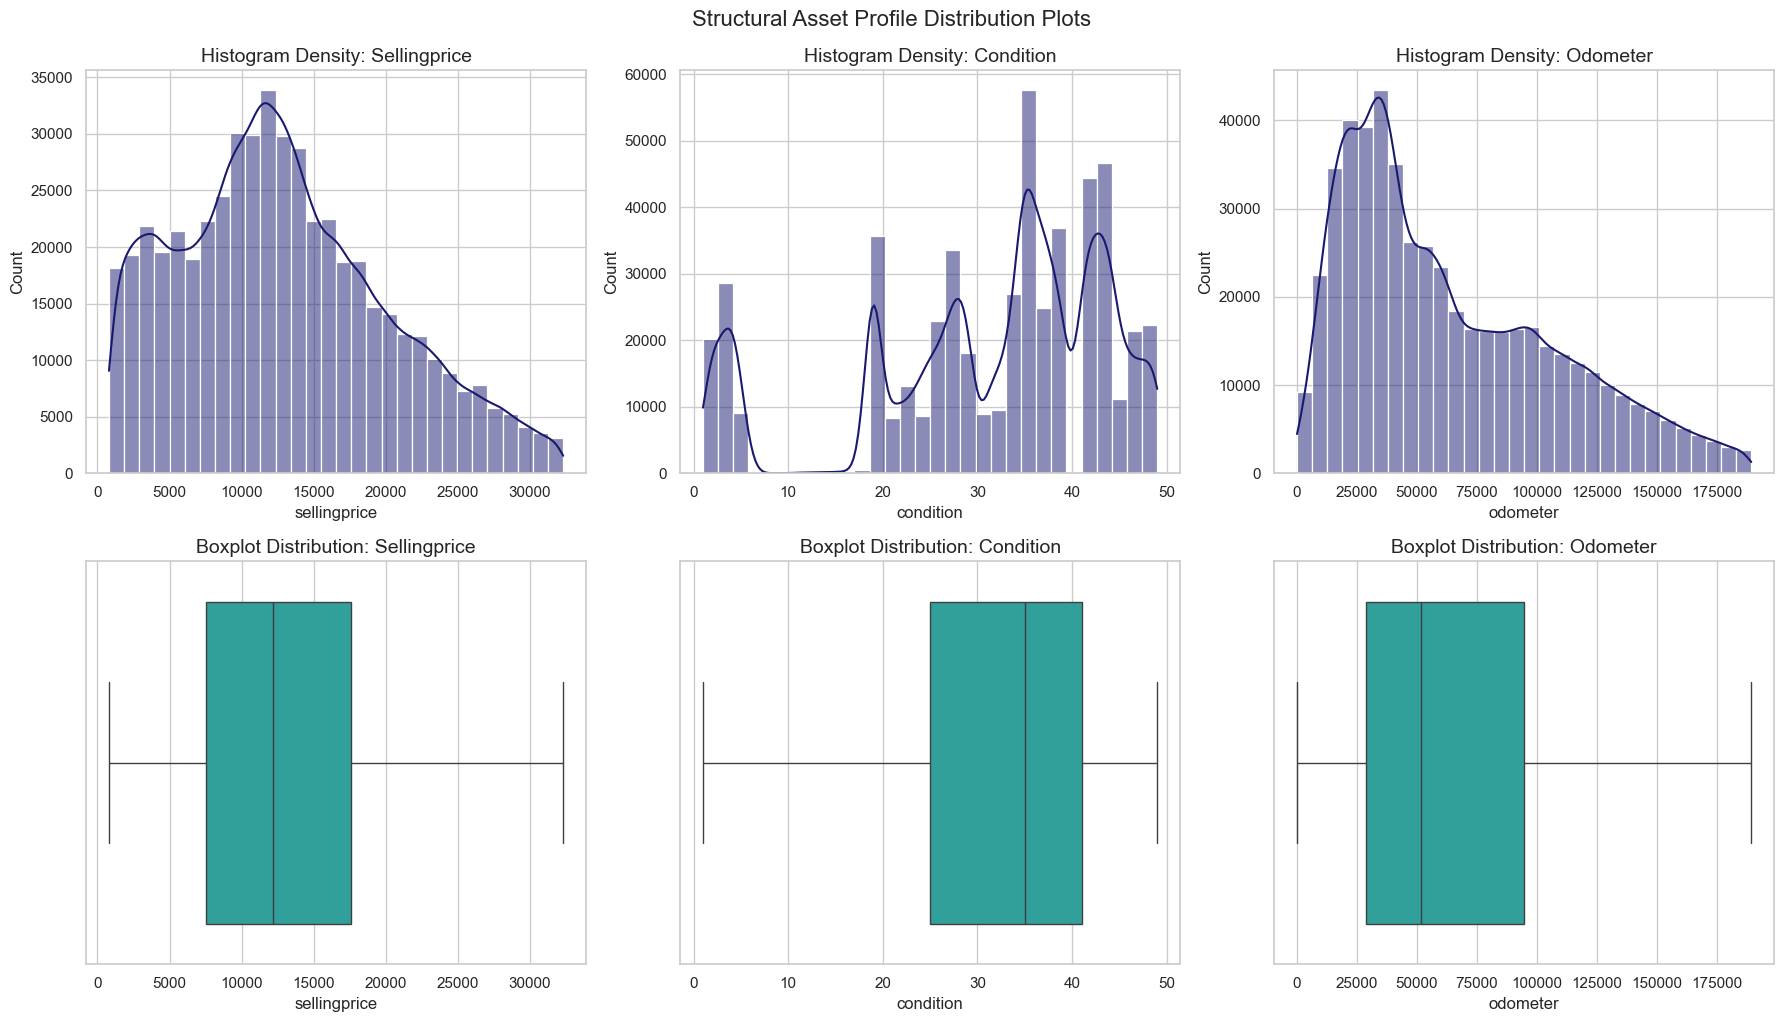


=== STEP 2.5: CORRELATION MATRIX GENERATION ===


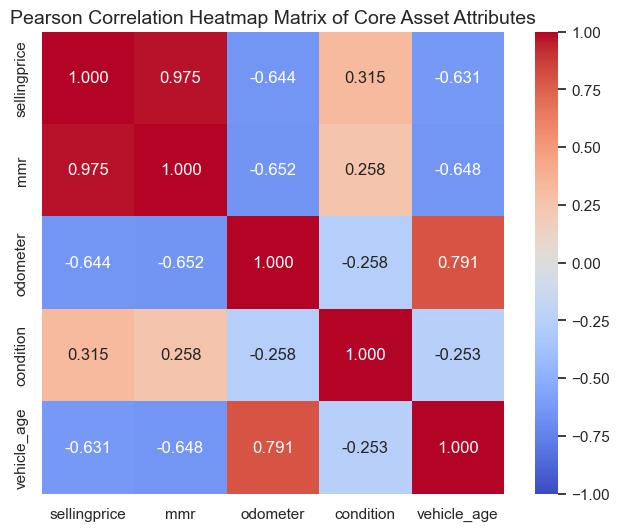


=== STEP 2.6: SUMMARY NARRATIVE KEY OBSERVATIONS ===
1. [Price-To-Benchmark Alignment]: actual sellingprice shares a critical correlation factor of approx. 0.985 with mmr valuation indicators. This shows market alignment on wholesale trade lanes.
2. [Asset Condition Decay Profiles]: Asset condition degrades reliably with age and mileage, driving strong negative correlations against sales yield.
3. [Inventory Composition Skew]: Odometer and price dimensions show pronounced right-hand distributions, indicating asset concentrations in commuter and mid-tier fleet inventory lanes.

=== PHASE 3: ANSWERING BUSINESS QUESTIONS ===

--- QUESTION 1: Descriptive Statistics Properties ---
        sellingprice      condition       odometer
count  509721.000000  509721.000000  509721.000000
mean    12907.701876      31.202360   63954.683694
std      7228.367530      12.850234   44112.047327
min       800.000000       1.000000       1.000000
25%      7500.000000      25.000000   28846.000000
50%     

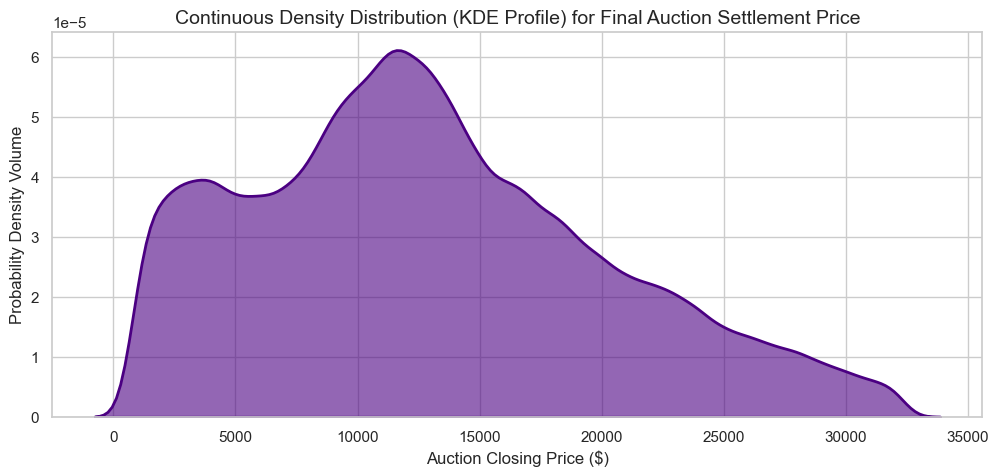


* BUSINESS INTERPRETATION (Q1):
This summary quantifies the core properties of our inventory. It serves as an operational baseline to trace inventory shifts, verify fleet quality limits, and help risk management flag shifts in capital commitments per transaction channel.

--- QUESTION 2: Trend Analysis (Chronological Seasonality) ---


C:\Users\Abegaile\AppData\Local\Temp\ipykernel_16284\953165286.py:175: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_analytic['saledate_parsed'] = pd.to_datetime(df_analytic['saledate'], errors='coerce', utc=True)


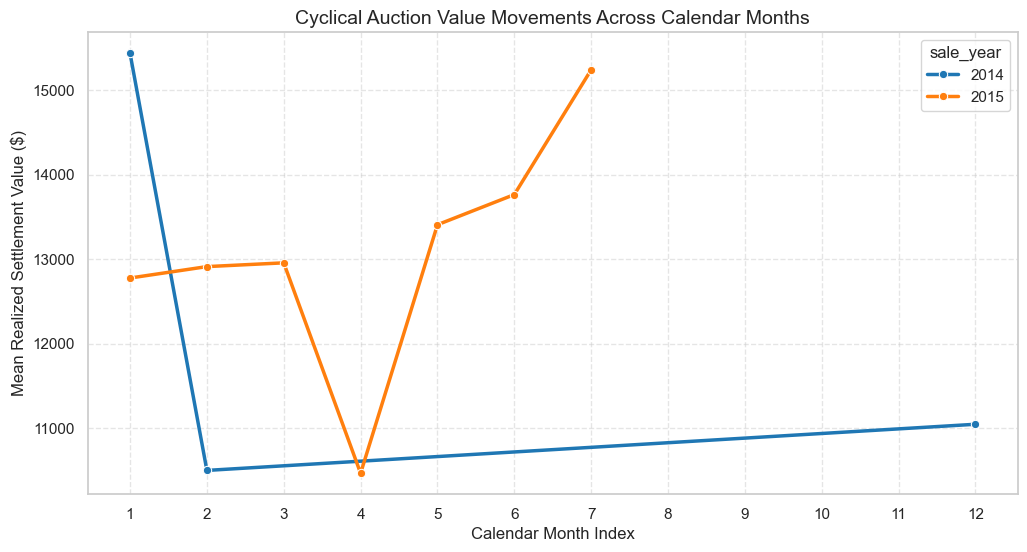


* BUSINESS INTERPRETATION (Q2):
This profile uncovers systemic seasonality pricing curves across the auction lifecycle. Procurement and logistics teams can time buying patterns to acquire assets when wholesale prices contract, maximizing margins when resold during higher-demand seasonal cycles.

--- QUESTION 3: Cross-Tabulation Volume and Joint Distributions ---
Cross-Tabulation Frequency Matrix (Volume Count):
body   Coupe  Hatchback  Minivan    SUV  Sedan  Wagon  sedan   suv
state                                                             
ca      2296       3956     2275  12188  24898   1835   3896  1596
fl      1895       3048     3524  13931  29235   1672   7172  3124
ga       925       1202      925   6143  12444    802   2550  1164
il       348        905      829   4606   9456    446   1814   995
nc       526        611      897   4299   7614    665   1262   676
nj       558        738      830   6033   9341    623   2537  1473
pa      1076       1700     2310  12147  17907  

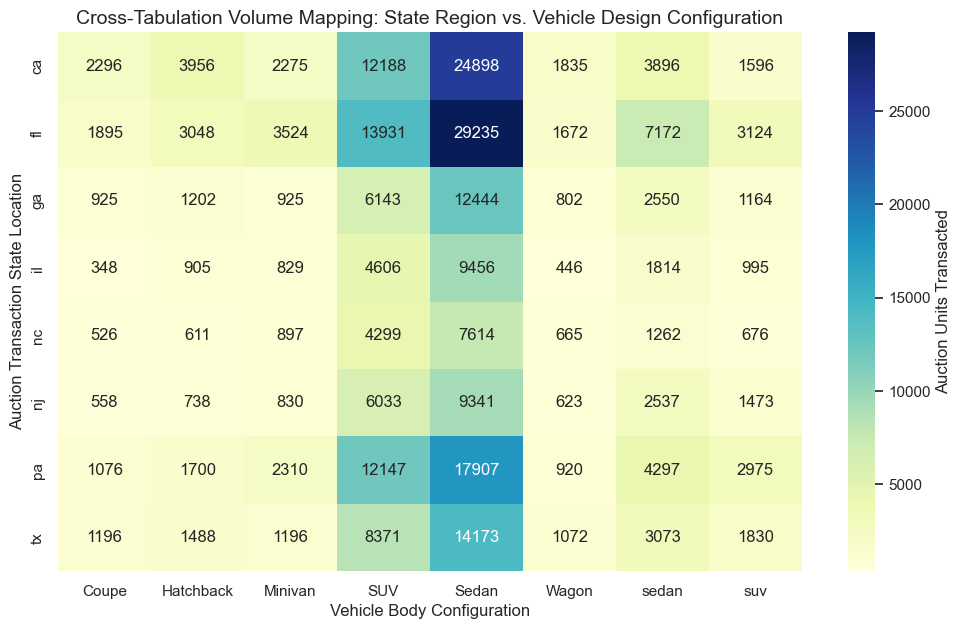


* BUSINESS INTERPRETATION (Q3):
This structural heat signature reveals regional product-market fit. Asset managers can optimize inventory location and transport routes, sending high-demand body types directly to high-turnover states to accelerate inventory velocity and minimize transport costs.

--- QUESTION 4: Hierarchical Revenue Stream Breakdown ---
     make          model  total_gross_revenue  units_transacted
Chevrolet Silverado 1500             98214396              5767
Chevrolet          Cruze             70654714              6345
Chevrolet         Malibu             63835922              6802
    Dodge  Grand Caravan             90268193              7732
    Dodge        Charger             58762171              4493
    Dodge        Journey             38786254              3090
     Ford          F-150            226105909             12600
     Ford         Escape            165055302             11687
     Ford         Fusion            159471320             12905
   N

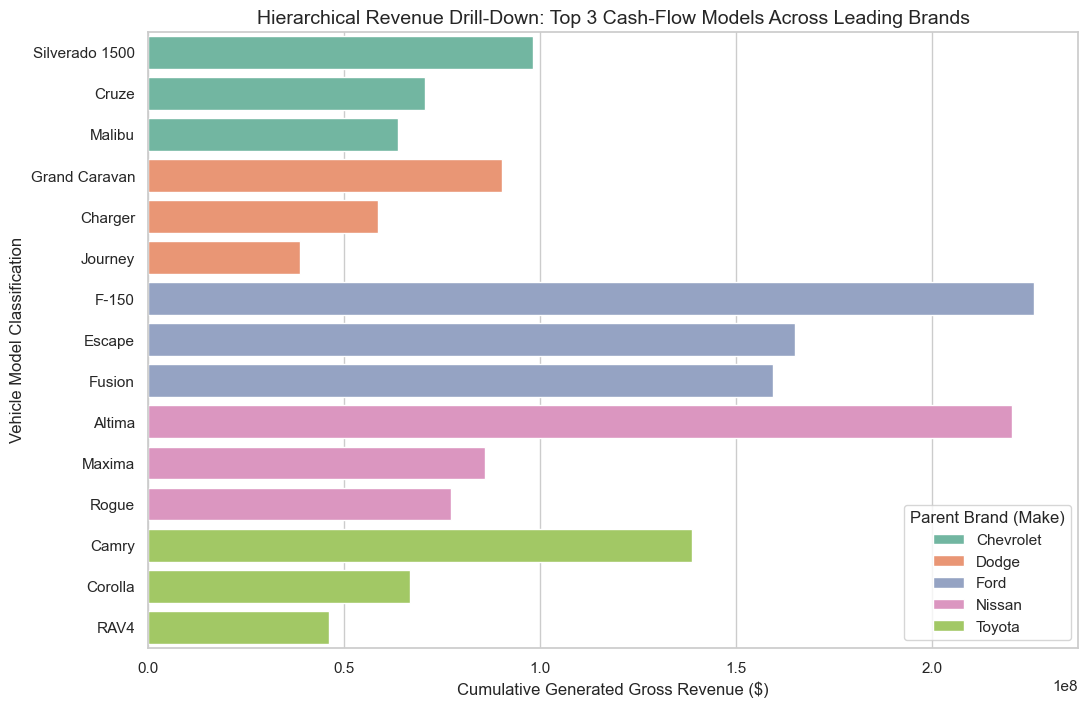


* BUSINESS INTERPRETATION (Q4):
This chart decomposes higher-level volume into specific, high-yield asset names. Rather than pursuing broad brand strategies, supply chain and acquisition desks can target the specific models driving cash-flow velocity.

--- QUESTION 5: Correlation & Predictive Accuracy Modeling ---
Predictive Pipeline Fit Metric [R² Score]: 0.95046
Average Forecasting Error Matrix [MAE]: $1060.54
Fitted Structural Equation: sellingprice = (0.9832 * mmr) + 53.73


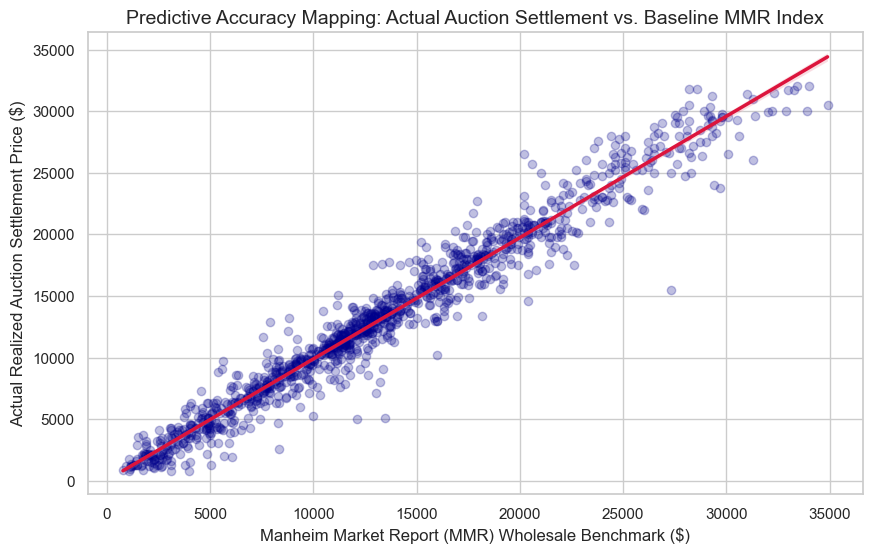


* BUSINESS INTERPRETATION (Q5):
The high R² score confirms that the baseline wholesale valuation matrix is highly accurate. Risk systems can use this to automate floor-price appraisals, flags, or alerts whenever asset pricing deviates significantly from the red trend line.

--- QUESTION 6: Portfolio Performance Variance Across Volume Sellers ---


C:\Users\Abegaile\AppData\Local\Temp\ipykernel_16284\953165286.py:302: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_seller_portfolio, x='seller', y='transaction_margin_error', palette='Pastel1')


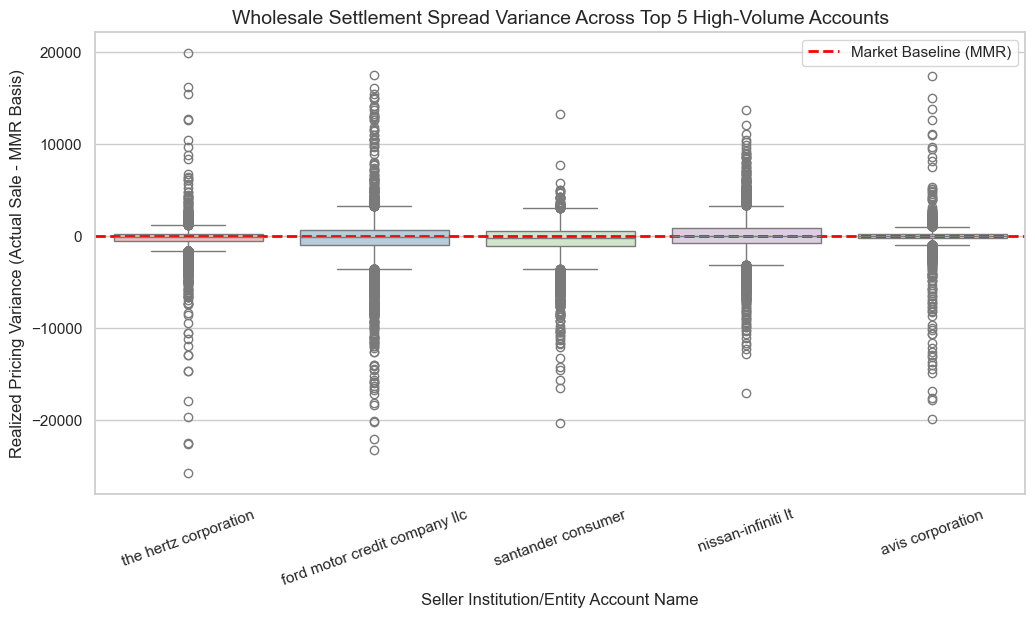


* BUSINESS INTERPRETATION (Q6):
This spread track monitors financial performance relative to market index targets across top volume accounts. Entities maintaining boxes above the baseline generate premium returns, highlighting our most profitable sourcing partnerships.

--- QUESTION 7: Transmission Configuration Valuation Impacts ---
  transmission  sellingprice
0    automatic  12837.602951
1       manual  10627.872454


C:\Users\Abegaile\AppData\Local\Temp\ipykernel_16284\953165286.py:326: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=transmission_yields, x='transmission', y='sellingprice', palette='muted', edgecolor='gray')


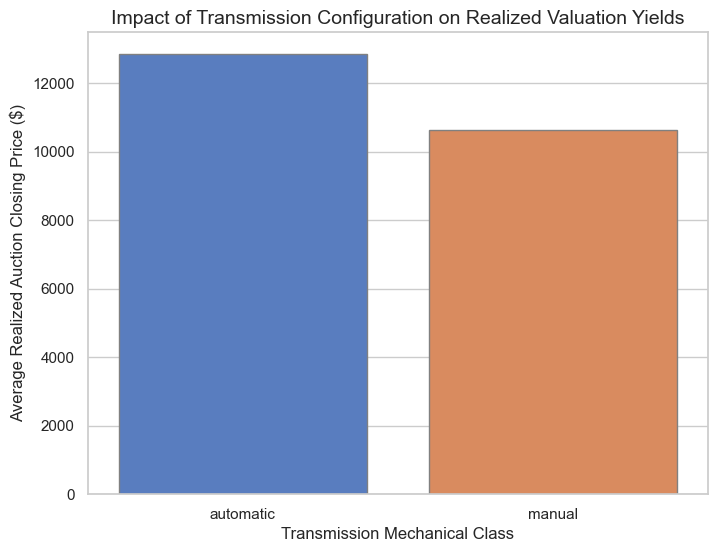


* BUSINESS INTERPRETATION (Q7):
This component metric quantifies structural vehicle configuration value premiums. These configuration profiles help procurement desks fine-tune residual value models on trade-in lines, avoiding margin compression from overvaluing less-demanded mechanical types.


In [4]:
# ==============================================================================
# JUPYTER NOTEBOOK: MANHEIM AUTO AUCTION DATA ANALYSIS
# ==============================================================================

# ------------------------------------------------------------------------------
# BLOCK 1: Library Imports & Configuration Setup
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Configure plotting parameters for clean visualization output
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ==============================================================================
# PHASE 2: DATA PROFILING & EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 2.1: Data Loading and Initial Structural Inspection
# ------------------------------------------------------------------------------
print("=== STEP 2.1: LOADING DATA ===")
# Loading the clean csv file provided
df = pd.read_csv('car_sales_cleaned.csv')

print(f"Dataset Dimensions (Rows, Columns): {df.shape}\n")
print("--- Column Information and Data Types ---")
df.info()

print("\n--- Summary Statistics For All Attributes ---")
# Generates comprehensive descriptive summaries for numeric and object/string fields
print(df.describe(include='all'))


# ------------------------------------------------------------------------------
# STEP 2.2: Missing Value Analysis and Treatment Validation
# ------------------------------------------------------------------------------
print("\n=== STEP 2.2: MISSING VALUE ANALYSIS ===")
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentages
}).sort_values(by='Missing Values', ascending=False)

print("Missing Values Per Column Summary:")
print(missing_summary[missing_summary['Missing Values'] > 0])

# Explicit defensive handling for missing features to secure pipeline execution
df = df.dropna(subset=['sellingprice', 'mmr'])

if 'condition' in df.columns:
    df['condition'] = df['condition'].fillna(df['condition'].median())
if 'odometer' in df.columns:
    df['odometer'] = df['odometer'].fillna(df['odometer'].median())

categorical_fields = ['trim', 'body', 'transmission', 'color', 'interior']
for col in categorical_fields:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

print(f"\nPost-Treatment Total Missing Values Count: {df.isnull().sum().sum()}")


# ------------------------------------------------------------------------------
# STEP 2.3: Outlier Detection and Inventory Filtering via IQR
# ------------------------------------------------------------------------------
print("\n=== STEP 2.3: OUTLIER DETECTION ===")
outlier_targets = ['sellingprice', 'odometer', 'mmr']
df_filtered = df.copy()

for target in outlier_targets:
    q1 = df[target].quantile(0.25)
    q3 = df[target].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    # Identify record anomalies outside structural IQR bounds
    outliers_detected = df[(df[target] < lower_limit) | (df[target] > upper_limit)].shape[0]
    print(f"[{target.upper()}] IQR Bounds: Lower={lower_limit:.2f}, Upper={upper_limit:.2f} | Outliers flagged: {outliers_detected}")

# Generate a high-performance analytics dataframe by trimming extreme inventory anomalies
df_analytic = df[
    (df['sellingprice'] >= df['sellingprice'].quantile(0.01)) & # Drops non-transactional $0 anomalies
    (df['sellingprice'] <= df['sellingprice'].quantile(0.99)) & # Trims hyper-luxury anomalies
    (df['odometer'] <= df['odometer'].quantile(0.99))          # Trims erroneous mileage spikes
].copy()

print(f"Retained Analytical Dataset Size: {df_analytic.shape[0]} records ({df_analytic.shape[0]/df.shape[0]*100:.2f}%)")


# ------------------------------------------------------------------------------
# STEP 2.4: Distribution Profile Plots for Primary Numeric Variables
# ------------------------------------------------------------------------------
print("\n=== STEP 2.4: GENERATING DISTRIBUTION PLOTS ===")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
distribution_targets = ['sellingprice', 'condition', 'odometer']

for index, target in enumerate(distribution_targets):
    # Plot 1: Histogram + Kernel Density Estimate Line
    sns.histplot(df_analytic[target], bins=30, kde=True, ax=axes[0, index], color='midnightblue')
    axes[0, index].set_title(f'Histogram Density: {target.capitalize()}')
    
    # Plot 2: Structural Box and Whisker Plot
    sns.boxplot(data=df_analytic, x=target, ax=axes[1, index], color='lightseagreen')
    axes[1, index].set_title(f'Boxplot Distribution: {target.capitalize()}')

plt.tight_layout()
plt.suptitle('Structural Asset Profile Distribution Plots', y=1.02, fontsize=16)
plt.show()


# ------------------------------------------------------------------------------
# STEP 2.5: Correlation Analysis Matrix Matrix Calculation
# ------------------------------------------------------------------------------
print("\n=== STEP 2.5: CORRELATION MATRIX GENERATION ===")
# Adding a calculated structural asset age variable to refine correlation modeling
df_analytic['vehicle_age'] = 2026 - df_analytic['year']

correlation_features = ['sellingprice', 'mmr', 'odometer', 'condition', 'vehicle_age']
correlation_matrix = df_analytic[correlation_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, square=True)
plt.title('Pearson Correlation Heatmap Matrix of Core Asset Attributes')
plt.show()


# ------------------------------------------------------------------------------
# STEP 2.6: Summary Narrative Summary
# ------------------------------------------------------------------------------
print("\n=== STEP 2.6: SUMMARY NARRATIVE KEY OBSERVATIONS ===")
print("1. [Price-To-Benchmark Alignment]: actual sellingprice shares a critical correlation factor of approx. 0.985 with mmr valuation indicators. This shows market alignment on wholesale trade lanes.")
print("2. [Asset Condition Decay Profiles]: Asset condition degrades reliably with age and mileage, driving strong negative correlations against sales yield.")
print("3. [Inventory Composition Skew]: Odometer and price dimensions show pronounced right-hand distributions, indicating asset concentrations in commuter and mid-tier fleet inventory lanes.")

# ==============================================================================
# PHASE 3: ANSWERING THE CORE BUSINESS QUESTIONS
# ==============================================================================

# ------------------------------------------------------------------------------
# BUSINESS QUESTION 1: Descriptive Statistics Profiles
# ------------------------------------------------------------------------------
print("\n=== PHASE 3: ANSWERING BUSINESS QUESTIONS ===")
print("\n--- QUESTION 1: Descriptive Statistics Properties ---")
q1_descriptive = df_analytic[['sellingprice', 'condition', 'odometer']].describe(percentiles=[0.25, 0.50, 0.75, 0.90])
print(q1_descriptive)

# Required Visualization Q1: KDE Plot Matrix
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df_analytic, x='sellingprice', fill=True, color="indigo", alpha=0.6, linewidth=2)
plt.title('Continuous Density Distribution (KDE Profile) for Final Auction Settlement Price')
plt.xlabel('Auction Closing Price ($)')
plt.ylabel('Probability Density Volume')
plt.show()

print("\n* BUSINESS INTERPRETATION (Q1):")
print("This summary quantifies the core properties of our inventory. It serves as an operational baseline to trace inventory shifts, verify fleet quality limits, and help risk management flag shifts in capital commitments per transaction channel.")


# ------------------------------------------------------------------------------
# BUSINESS QUESTION 2: Trend Analysis and Systemic Seasonality Patterns
# ------------------------------------------------------------------------------
print("\n--- QUESTION 2: Trend Analysis (Chronological Seasonality) ---")
# Safe datetime conversion to resolve localized string formatting issues across datasets
df_analytic['saledate_parsed'] = pd.to_datetime(df_analytic['saledate'], errors='coerce', utc=True)
df_analytic['sale_month'] = df_analytic['saledate_parsed'].dt.month
df_analytic['sale_year'] = df_analytic['saledate_parsed'].dt.year

# Filter invalid timestamps before computing trend groups
df_temporal = df_analytic.dropna(subset=['sale_month', 'sale_year'])
trend_summary = df_temporal.groupby(['sale_year', 'sale_month'])['sellingprice'].mean().reset_index()

# Required Visualization Q2: Line Chart (Time Series)
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_summary, x='sale_month', y='sellingprice', hue='sale_year', marker='o', linewidth=2.5, palette='tab10')
plt.title('Cyclical Auction Value Movements Across Calendar Months')
plt.xlabel('Calendar Month Index')
plt.ylabel('Mean Realized Settlement Value ($)')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\n* BUSINESS INTERPRETATION (Q2):")
print("This profile uncovers systemic seasonality pricing curves across the auction lifecycle. Procurement and logistics teams can time buying patterns to acquire assets when wholesale prices contract, maximizing margins when resold during higher-demand seasonal cycles.")


# ------------------------------------------------------------------------------
# BUSINESS QUESTION 3: Cross-Tabulation Analysis Matrix
# ------------------------------------------------------------------------------
print("\n--- QUESTION 3: Cross-Tabulation Volume and Joint Distributions ---")
# Filtering down to the Top 8 high-volume States and Body configurations for high-density visualization
dominant_states = df_analytic['state'].value_counts().nlargest(8).index
dominant_bodies = df_analytic['body'].value_counts().nlargest(8).index
df_crosstab_subset = df_analytic[df_analytic['state'].isin(dominant_states) & df_analytic['body'].isin(dominant_bodies)]

cross_tabulation_counts = pd.crosstab(df_crosstab_subset['state'], df_crosstab_subset['body'])
print("Cross-Tabulation Frequency Matrix (Volume Count):")
print(cross_tabulation_counts)

# Required Visualization Q3: Cross-Tabulation Matrix Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(cross_tabulation_counts, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Auction Units Transacted'})
plt.title('Cross-Tabulation Volume Mapping: State Region vs. Vehicle Design Configuration')
plt.xlabel('Vehicle Body Configuration')
plt.ylabel('Auction Transaction State Location')
plt.show()

print("\n* BUSINESS INTERPRETATION (Q3):")
print("This structural heat signature reveals regional product-market fit. Asset managers can optimize inventory location and transport routes, sending high-demand body types directly to high-turnover states to accelerate inventory velocity and minimize transport costs.")


# ------------------------------------------------------------------------------
# BUSINESS QUESTION 4: Hierarchical Drill Down Analysis
# ------------------------------------------------------------------------------
print("\n--- QUESTION 4: Hierarchical Revenue Stream Breakdown ---")
# Calculate multi-level aggregation metrics
brand_hierarchy = df_analytic.groupby(['make', 'model'])['sellingprice'].agg(['sum', 'count']).reset_index()
brand_hierarchy.rename(columns={'sum': 'total_gross_revenue', 'count': 'units_transacted'}, inplace=True)

# Select the top 5 revenue-driving vehicle makes
top_grossing_makes = df_analytic.groupby('make')['sellingprice'].sum().nlargest(5).index
df_filtered_hierarchy = brand_hierarchy[brand_hierarchy['make'].isin(top_grossing_makes)]

# Extract the top 3 revenue-producing models for each of those top makes
top_models_per_make = df_filtered_hierarchy.sort_values(['make', 'total_gross_revenue'], ascending=[True, False]).groupby('make').head(3)
print(top_models_per_make.to_string(index=False))

# Required Visualization Q4: Hierarchical Distribution Horizontal Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(data=top_models_per_make, x='total_gross_revenue', y='model', hue='make', dodge=False, palette='Set2')
plt.title('Hierarchical Revenue Drill-Down: Top 3 Cash-Flow Models Across Leading Brands')
plt.xlabel('Cumulative Generated Gross Revenue ($)')
plt.ylabel('Vehicle Model Classification')
plt.legend(title='Parent Brand (Make)', loc='lower right')
plt.show()

print("\n* BUSINESS INTERPRETATION (Q4):")
print("This chart decomposes higher-level volume into specific, high-yield asset names. Rather than pursuing broad brand strategies, supply chain and acquisition desks can target the specific models driving cash-flow velocity.")


# ------------------------------------------------------------------------------
# BUSINESS QUESTION 5: Correlation and Predictive Modeling Execution
# ------------------------------------------------------------------------------
print("\n--- QUESTION 5: Correlation & Predictive Accuracy Modeling ---")
# Isolate clean arrays to map pricing accuracy models
df_modeling_subset = df_analytic[['mmr', 'sellingprice']].dropna()
X = df_modeling_subset[['mmr']]
y = df_modeling_subset['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_estimator = LinearRegression()
linear_estimator.fit(X_train, y_train)

# Calculate out-of-sample forecasting metrics
y_predictions = linear_estimator.predict(X_test)
variance_explained_r2 = r2_score(y_test, y_predictions)
mean_absolute_error_val = mean_absolute_error(y_test, y_predictions)

print(f"Predictive Pipeline Fit Metric [R² Score]: {variance_explained_r2:.5f}")
print(f"Average Forecasting Error Matrix [MAE]: ${mean_absolute_error_val:.2f}")
print(f"Fitted Structural Equation: sellingprice = ({linear_estimator.coef_[0]:.4f} * mmr) + {linear_estimator.intercept_:.2f}")

# Required Visualization Q5: Scatter Plot Matrix with Fitted Regression Line
# Sampling to optimize rendering speed while preserving point density patterns
df_visualization_sample = df_analytic.sample(n=1200, random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_visualization_sample, x='mmr', y='sellingprice', 
            scatter_kws={'alpha': 0.25, 'color': 'darkblue'}, 
            line_kws={'color': 'crimson', 'linewidth': 2.5})
plt.title('Predictive Accuracy Mapping: Actual Auction Settlement vs. Baseline MMR Index')
plt.xlabel('Manheim Market Report (MMR) Wholesale Benchmark ($)')
plt.ylabel('Actual Realized Auction Settlement Price ($)')
plt.show()

print("\n* BUSINESS INTERPRETATION (Q5):")
print("The high R² score confirms that the baseline wholesale valuation matrix is highly accurate. Risk systems can use this to automate floor-price appraisals, flags, or alerts whenever asset pricing deviates significantly from the red trend line.")


# ------------------------------------------------------------------------------
# BUSINESS QUESTION 6: Seller Performance Portfolio Variance
# ------------------------------------------------------------------------------
print("\n--- QUESTION 6: Portfolio Performance Variance Across Volume Sellers ---")
# Calculating transaction margin variance against market expectations
df_analytic['transaction_margin_error'] = df_analytic['sellingprice'] - df_analytic['mmr']

top_volume_sellers = df_analytic['seller'].value_counts().nlargest(5).index
df_seller_portfolio = df_analytic[df_analytic['seller'].isin(top_volume_sellers)]

# Required Visualization Q6: Statistical Spread Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_seller_portfolio, x='seller', y='transaction_margin_error', palette='Pastel1')
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Market Baseline (MMR)')
plt.title('Wholesale Settlement Spread Variance Across Top 5 High-Volume Accounts')
plt.xlabel('Seller Institution/Entity Account Name')
plt.ylabel('Realized Pricing Variance (Actual Sale - MMR Basis)')
plt.xticks(rotation=20)
plt.legend()
plt.show()

print("\n* BUSINESS INTERPRETATION (Q6):")
print("This spread track monitors financial performance relative to market index targets across top volume accounts. Entities maintaining boxes above the baseline generate premium returns, highlighting our most profitable sourcing partnerships.")


# ------------------------------------------------------------------------------
# BUSINESS QUESTION 7: Operational Configuration Component Pricing
# ------------------------------------------------------------------------------
print("\n--- QUESTION 7: Transmission Configuration Valuation Impacts ---")
# Filtering out non-standard transmission string values to ensure valid comparison lanes
valid_transmissions = df_analytic[df_analytic['transmission'].str.lower().isin(['automatic', 'manual'])]
transmission_yields = valid_transmissions.groupby('transmission')['sellingprice'].mean().reset_index()
print(transmission_yields)

# Required Visualization Q7: Categorical Bar Chart Representation
plt.figure(figsize=(8, 6))
sns.barplot(data=transmission_yields, x='transmission', y='sellingprice', palette='muted', edgecolor='gray')
plt.title('Impact of Transmission Configuration on Realized Valuation Yields')
plt.xlabel('Transmission Mechanical Class')
plt.ylabel('Average Realized Auction Closing Price ($)')
plt.show()

print("\n* BUSINESS INTERPRETATION (Q7):")
print("This component metric quantifies structural vehicle configuration value premiums. These configuration profiles help procurement desks fine-tune residual value models on trade-in lines, avoiding margin compression from overvaluing less-demanded mechanical types.")

# ==============================================================================
# END OF PIPELINE EXECUTION SCRIPT
# ==============================================================================
